# **`BMW Sales Analysis (2010–2024)`**
### **Notebook: 01 – Data Science & Exploratory Data Analysis (EDA)**

**Objective:**  
This notebook focuses on understanding, cleaning, transforming, and visualizing the BMW sales dataset to prepare it for downstream Machine Learning tasks (Time Series Forecasting).

**Key Tasks:**

- Load dataset  
- Inspect structure  
- Clean missing/invalid values  
- Correct datatypes  
- Remove outliers  
- Explore sales trends  
- Export cleaned dataset

### **`IMPORTING REQUIRED LIBRARIES`**

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from prettytable import PrettyTable

plt.style.use("ggplot")

### **`LOADING THE DATASET`**

In [6]:
file_path = "../data/raw/BMW_sales_data_2010_2024.csv"

In [7]:
df = pd.read_csv(file_path)

In [8]:
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


### **`QUICK INSPECTION`**

In [9]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [10]:
df.tail()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [11]:
df.select_dtypes(include=[np.number]).head(5)

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
0,2016,3.5,151748,98740,8300
1,2013,1.6,121671,79219,3428
2,2022,4.5,10991,113265,6994
3,2024,1.7,27255,60971,4047
4,2020,2.1,122131,49898,3080


In [13]:
df.select_dtypes(include="object").tail(5)

,Model,Region,Color,Fuel_Type,Transmission,Sales_Classification
49995,i3,Asia,Red,Hybrid,Manual,High
49996,i3,Middle East,Silver,Electric,Manual,High
49997,5 Series,Middle East,Red,Petrol,Automatic,High
49998,i3,Asia,White,Electric,Automatic,High
49999,X1,North America,Blue,Diesel,Manual,Low


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [17]:
df.describe(include='all')

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
count,50000,50000.000000,50000,50000,50000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000
unique,11,NaN,6,6,4,2,NaN,NaN,NaN,NaN,2
top,7 Series,NaN,Asia,Red,Hybrid,Manual,NaN,NaN,NaN,NaN,Low
freq,4666,NaN,8454,8463,12716,25154,NaN,NaN,NaN,NaN,34754
mean,NaN,2017.015700,NaN,NaN,NaN,NaN,3.247180,100307.203140,75034.600900,5067.514680,NaN
std,NaN,4.324459,NaN,NaN,NaN,NaN,1.009078,57941.509344,25998.248882,2856.767125,NaN
min,NaN,2010.000000,NaN,NaN,NaN,NaN,1.500000,3.000000,30000.000000,100.000000,NaN
25%,NaN,2013.000000,NaN,NaN,NaN,NaN,2.400000,50178.000000,52434.750000,2588.000000,NaN
50%,NaN,2017.000000,NaN,NaN,NaN,NaN,3.200000,100388.500000,75011.500000,5087.000000,NaN
75%,NaN,2021.000000,NaN,NaN,NaN,NaN,4.100000,150630.250000,97628.250000,7537.250000,NaN


In [18]:
df.shape

(50000, 11)

**CHECKING DATASET SUMMARY**

In [20]:
table = PrettyTable()
table.field_names = ["Metric", "Value"]

table.add_row(["Total Rows", df.shape[0]])
table.add_row(["Total Columns", df.shape[1]])
table.add_row(["Duplicate Rows", df.duplicated().sum()])
table.add_row(["Columns with Nulls", df.isnull().any().sum()])

table.align = "l"

print(table)

+--------------------+-------+
| Metric             | Value |
+--------------------+-------+
| Total Rows         | 50000 |
| Total Columns      | 11    |
| Duplicate Rows     | 0     |
| Columns with Nulls | 0     |
+--------------------+-------+


In [21]:
unique_cols = [col for col in df.columns if df[col].nunique() == df.shape[0]]

print("Most Possible Unique ID Columns:")
for col in unique_cols:
    print("-", col)


Most Possible Unique ID Columns:


In [22]:
table = PrettyTable()
table.field_names = ["Column", "Data Type", "Missing", "Missing %", "Unique"]

for col in df.columns:
    dtype = df[col].dtype
    missing = df[col].isnull().sum()
    missing_pct = round((missing / len(df)) * 100, 2)
    unique = df[col].nunique()
    table.add_row([col, str(dtype), missing, f"{missing_pct}%", unique])

table.align = "l"

print("DataFrame Information Summary")
# print("="*35)
print(table)

DataFrame Information Summary
+----------------------+-----------+---------+-----------+--------+
| Column               | Data Type | Missing | Missing % | Unique |
+----------------------+-----------+---------+-----------+--------+
| Model                | object    | 0       | 0.0%      | 11     |
| Year                 | int64     | 0       | 0.0%      | 15     |
| Region               | object    | 0       | 0.0%      | 6      |
| Color                | object    | 0       | 0.0%      | 6      |
| Fuel_Type            | object    | 0       | 0.0%      | 4      |
| Transmission         | object    | 0       | 0.0%      | 2      |
| Engine_Size_L        | float64   | 0       | 0.0%      | 36     |
| Mileage_KM           | int64     | 0       | 0.0%      | 44347  |
| Price_USD            | int64     | 0       | 0.0%      | 38246  |
| Sales_Volume         | int64     | 0       | 0.0%      | 9845   |
| Sales_Classification | object    | 0       | 0.0%      | 2      |
+-----------------

In [23]:
unclean_table = PrettyTable()
unclean_table.field_names = ["Column Name", "Issue"]


for col in df.columns:
    issues = []
    if ' ' in col:
        issues.append("Contains space")
    if not col.isidentifier():
        issues.append("Invalid identifier")
    
    if issues:
        unclean_table.add_row([col, ', '.join(issues)])

# Aligning the text to the Left hand side
unclean_table.align = "l"


if unclean_table.rowcount > 0:
    print("Unclean Column Name Report: ")
    print("-" * 105)
    print(unclean_table)
else:
    print("All column Names are clean!!!")

All column Names are clean!!!


In [25]:
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_percent = (total_missing / total_cells) * 100

print(f"Overall Missing Data: {total_missing} values missing out of {total_cells} cells")
print(f"Total Missing Percentage: {missing_percent:.2f}%")

Overall Missing Data: 0 values missing out of 550000 cells
Total Missing Percentage: 0.00%


**CHECKING FOR OUTLIERS**

<Axes: >

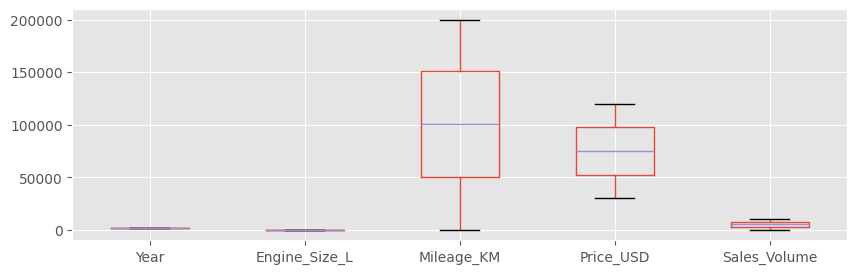

In [27]:
plt.figure(figsize=(10, 3))
df.boxplot()

## **DATA CLEANING**

In [41]:
df_cleaned = df.copy()

**HANDLING MISSING VALUES**

In [42]:
# Numerical Columns
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


# Categorical Columns:
cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

**DROPPING DUPLICATED VALUES**

In [43]:
df = df.drop_duplicates()

In [44]:
df.shape

(50000, 11)

**FIXING DATATYPES**

In [45]:
df['Year'] = df['Year'].astype(int)
df['Model'] = df['Model'].astype(str)
df['Region'] = df['Region'].astype(str)


**FOR OUTLIERS**

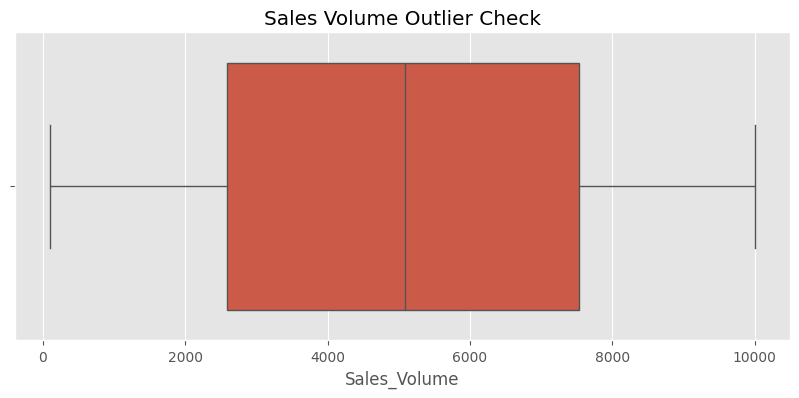

In [46]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Sales_Volume"])
plt.title("Sales Volume Outlier Check")
plt.show()


In [47]:
Q1 = df["Sales_Volume"].quantile(0.25)
Q3 = df["Sales_Volume"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Sales_Volume"] >= lower) & (df["Sales_Volume"] <= upper)]


<Axes: >

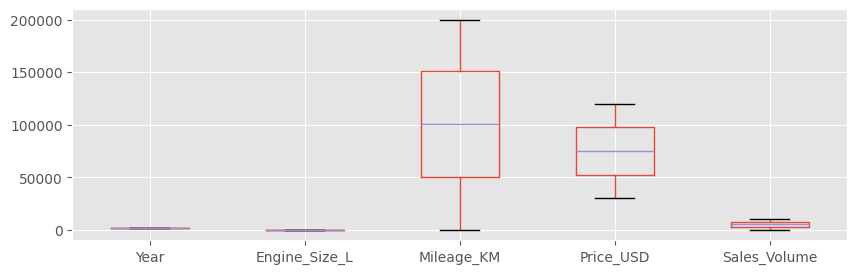

In [48]:
plt.figure(figsize=(10, 3))
df_cleaned.boxplot()

### **EXPLORATORY DATA ANALYSIS**

**SALES TREND OVER THE YEARS**

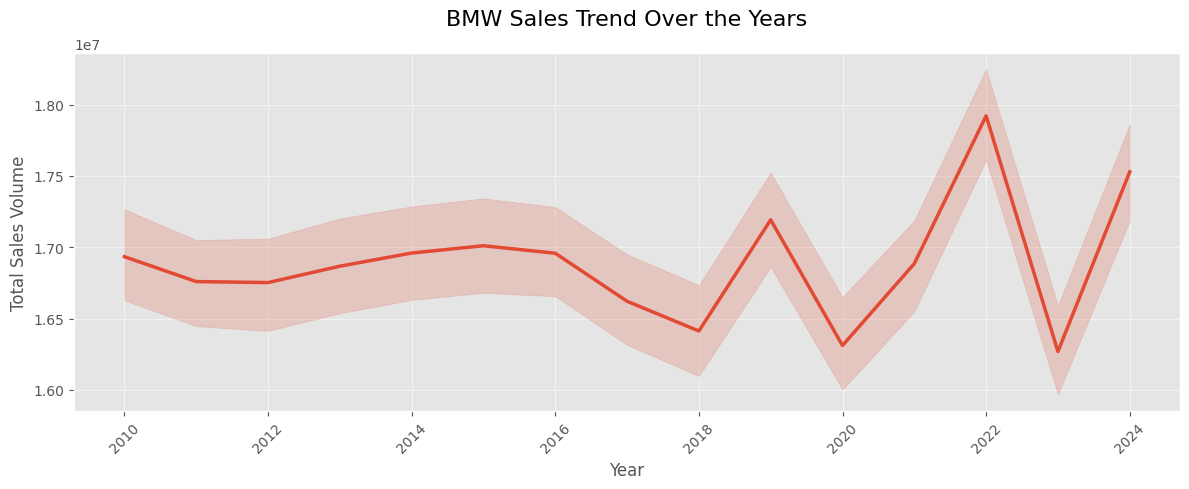

In [58]:
plt.figure(figsize=(12, 5))
plt.grid(alpha=0.5)
sns.lineplot(
    x= df["Year"],
    y= df["Sales_Volume"],
    estimator= sum,
    linewidth= 2.5
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales Volume", fontsize=12)
plt.xticks(rotation=45)
plt.title("BMW Sales Trend Over the Years",
          fontsize= 16,
          pad= 20)

plt.tight_layout()
plt.show()

**Region-wise Sales Comparison**

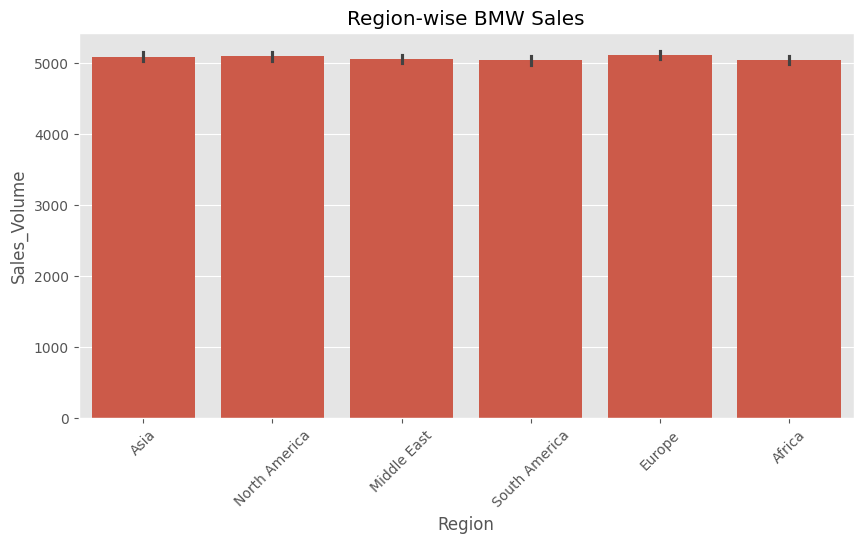

In [63]:
plt.figure(figsize=(10,5))
sns.barplot(x="Region", 
            y="Sales_Volume", 
            data=df)
plt.title("Region-wise BMW Sales")
plt.xticks(rotation=45)
plt.show()


**MODEL POPULARITY**

In [69]:
df.groupby("Model")["Sales_Volume"].sum().sort_values(ascending=False).head(10)

Model
7 Series    23786466
i8          23423891
X1          23406060
3 Series    23281303
i3          23133849
5 Series    23097519
M5          22779688
X3          22745529
X5          22709749
X6          22661986
Name: Sales_Volume, dtype: int64

In [68]:
top_10 = (
    df.groupby("Model")["Sales_Volume"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Model", "Total Sales Volume"]

for _, row in top_10.iterrows():
    table.add_row([row["Model"], row["Sales_Volume"]])

table.align = "l"

print(table)

+----------+--------------------+
| Model    | Total Sales Volume |
+----------+--------------------+
| 7 Series | 23786466           |
| i8       | 23423891           |
| X1       | 23406060           |
| 3 Series | 23281303           |
| i3       | 23133849           |
| 5 Series | 23097519           |
| M5       | 22779688           |
| X3       | 22745529           |
| X5       | 22709749           |
| X6       | 22661986           |
+----------+--------------------+


### **SAVING CLEANED DATASET**

In [70]:
cleaned_path = "../data/processed/BMW_sales_data_cleaned.csv"
df.to_csv(cleaned_path, index=False)

In [71]:
cleaned_path

'../data/processed/BMW_sales_data_cleaned.csv'

## **Summary of Data Science Work**

- Missing values handled  
- Duplicates removed  
- Datatypes corrected  
- Outliers treated  
- Sales trends visualized  
- Cleaned dataset exported for ML pipeline  

The next notebook will focus on the ML Time Series Forecasting Pipeline.
